# fAIr predict ; minimal examples

Uses knative cold start for containers ; POST a bbox + tile URL + ONNX URI to a fAIr predict endpoint, render the returned GeoJSON.

```
uv run --with httpx --with geopandas --with matplotlib --with jupyter jupyter lab
```

In [ ]:
import geopandas as gpd
import httpx

BASE = "https://predict.fair.krschap.tech"
IMAGE_URI = "https://tiles.openaerialmap.org/62d85d11d8499800053796c1/0/62d85d11d8499800053796c2/{z}/{x}/{y}"
BBOX = [85.51678033745037, 27.6313353660439, 85.52323021107895, 27.637438390948745]
ZOOM = 18


def call_predict(service: str, model_uri: str, params: dict) -> gpd.GeoDataFrame:
    payload = {
        "model_uri": model_uri,
        "image_uri": IMAGE_URI,
        "bbox": BBOX,
        "zoom": ZOOM,
        "params": params,
    }
    resp = httpx.post(f"{BASE}/{service}/predict", json=payload, timeout=300)
    resp.raise_for_status()
    gdf = gpd.GeoDataFrame.from_features(resp.json()["features"])
    if not gdf.empty:
        gdf.set_crs("EPSG:4326", inplace=True)
    return gdf


def plot(gdf: gpd.GeoDataFrame, title: str):
    color = next((c for c in ("label", "class") if c in gdf.columns), None)
    ax = gdf.plot(column=color, legend=color is not None, edgecolor="black", linewidth=0.3, alpha=0.6, figsize=(8, 8))
    ax.set_title(f"{title}  (n={len(gdf)})")
    return ax

## ResNet18 classification

In [22]:
gdf = call_predict(
    service="resnet18-classification",
    model_uri="https://nyc3.digitaloceanspaces.com/hotosm-fair/zenml/base-models/resnet18-classification/model/resnet18_classification.onnx",
    params={"confidence_threshold": 0.5},
)
print(f"features: {len(gdf)}")
gdf.head()

HTTP Request: POST https://predict.fair.krschap.tech/resnet18-classification/predict "HTTP/1.1 200 OK"
features: 36


,geometry,label,confidence,source
0,"POLYGON ((85.5162 27.63731, 85.51758 27.63731,...",no_building,0.3391,OAM-193343-110117-18.tif
1,"POLYGON ((85.5162 27.63609, 85.51758 27.63609,...",no_building,0.3988,OAM-193343-110118-18.tif
2,"POLYGON ((85.5162 27.63487, 85.51758 27.63487,...",no_building,0.4070,OAM-193343-110119-18.tif
3,"POLYGON ((85.5162 27.63366, 85.51758 27.63366,...",no_building,0.4011,OAM-193343-110120-18.tif
4,"POLYGON ((85.5162 27.63244, 85.51758 27.63244,...",no_building,0.4641,OAM-193343-110121-18.tif


<Axes: title={'center': 'resnet18-classification  (n=36)'}>

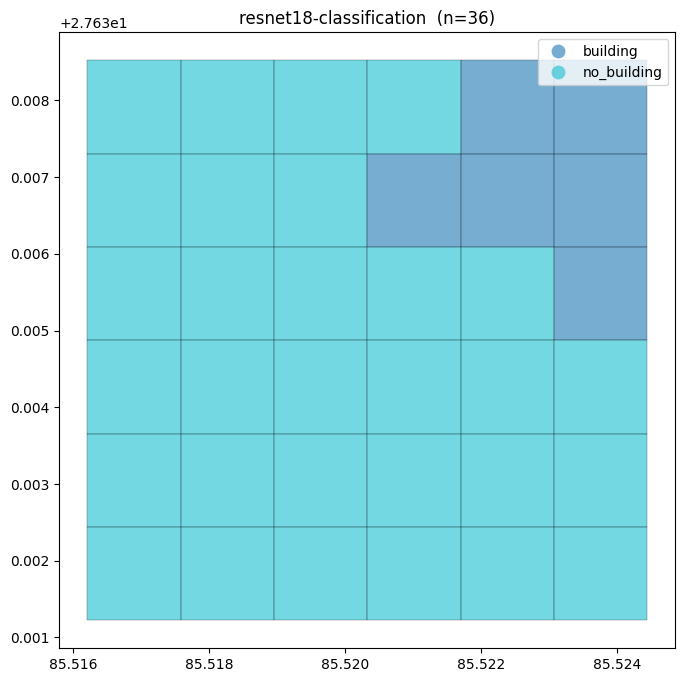

In [23]:
plot(gdf, "resnet18-classification")

## UNet segmentation

In [24]:
gdf = call_predict(
    service="unet-segmentation",
    model_uri="https://nyc3.digitaloceanspaces.com/hotosm-fair/zenml/local-models/4a98e66d-e7e1-4ea0-864f-de02b0a8d0d2/model/4a98e66d-e7e1-4ea0-864f-de02b0a8d0d2.onnx",
    params={"confidence_threshold": 0.5, "min_class_value": 1},
)
print(f"features: {len(gdf)}")
gdf.head()

HTTP Request: POST https://predict.fair.krschap.tech/unet-segmentation/predict "HTTP/1.1 200 OK"
features: 1060


,geometry,class
0,"POLYGON ((85.5162 27.63852, 85.5162 27.63844, ...",1
1,"POLYGON ((85.51679 27.63852, 85.51679 27.63852...",1
2,"POLYGON ((85.51757 27.63848, 85.51757 27.63848...",1
3,"POLYGON ((85.51729 27.63852, 85.51729 27.63852...",1
4,"POLYGON ((85.51681 27.6383, 85.51681 27.63829,...",1


<Axes: title={'center': 'unet-segmentation  (n=1060)'}>

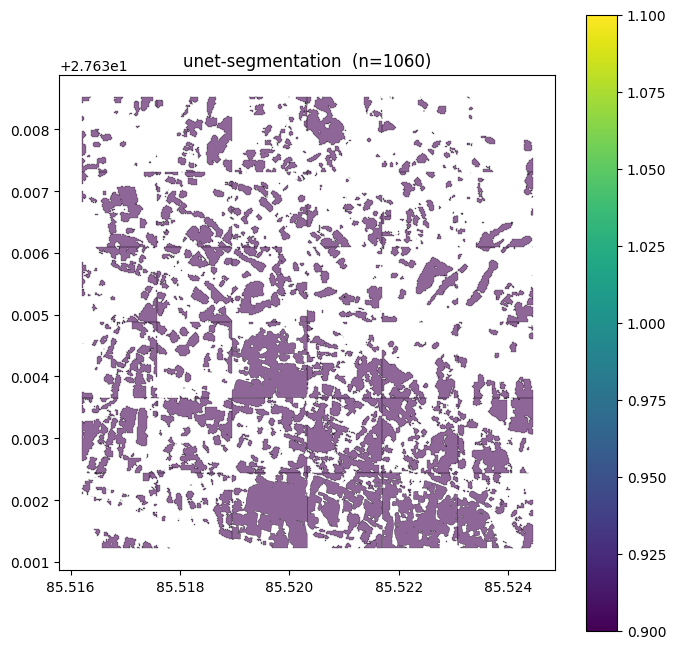

In [25]:
plot(gdf, "unet-segmentation")

## YOLO11n detection

In [26]:
gdf = call_predict(
    service="yolo11n-detection",
    model_uri="https://nyc3.digitaloceanspaces.com/hotosm-fair/zenml/base-models/yolo11n-detection/model/yolo11n_detection.onnx",
    params={"confidence_threshold": 0.25, "iou_threshold": 0.45},
)
print(f"features: {len(gdf)}")
gdf.head()

HTTP Request: POST https://predict.fair.krschap.tech/yolo11n-detection/predict "HTTP/1.1 200 OK"
features: 5


,geometry,confidence,class,source
0,"POLYGON ((85.51652 27.63756, 85.51666 27.63756...",0.3975,62,OAM-193343-110117-18.tif
1,"POLYGON ((85.51787 27.63386, 85.5183 27.63386,...",0.3577,13,OAM-193344-110120-18.tif
2,"POLYGON ((85.5179 27.63203, 85.51804 27.63203,...",0.5079,62,OAM-193344-110122-18.tif
3,"POLYGON ((85.51896 27.63397, 85.5193 27.63397,...",0.2788,25,OAM-193345-110120-18.tif
4,"POLYGON ((85.52344 27.63371, 85.52355 27.63371...",0.4971,2,OAM-193348-110120-18.tif


<Axes: title={'center': 'yolo11n-detection  (n=5)'}>

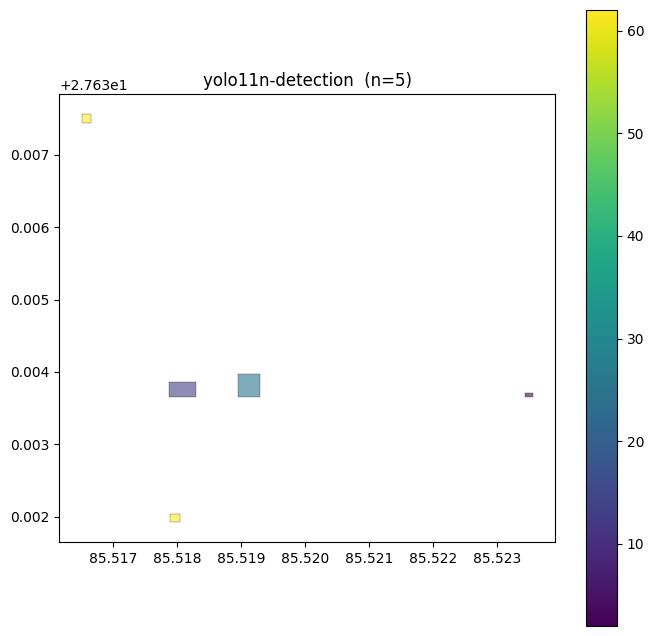

In [27]:
plot(gdf, "yolo11n-detection")